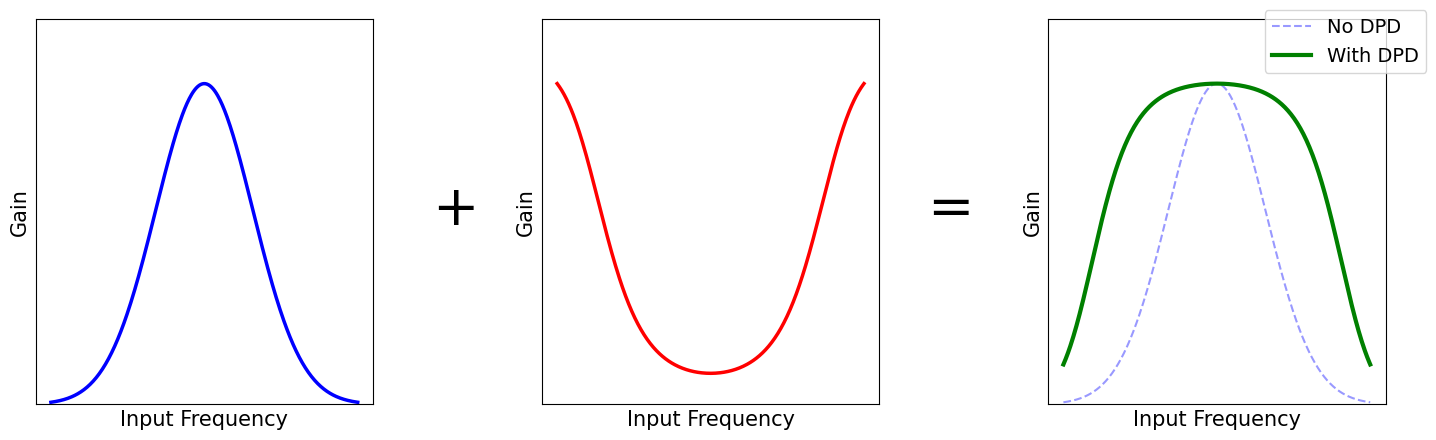

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the frequency range
f = np.linspace(-2, 2, 400)

# 1. PA Frequency Response (Linear Distortion)
# A simple low-pass characteristic (e.g., Gaussian-like roll-off)
pa_response = np.exp(- (f**2) / 0.8)

# 2. DPD Profile (Inverse Filter)
# To avoid infinity at edges, we can use a clipping or regularized inverse
# This is the "boost" to compensate for the roll-off
dpd_response = 1.0 / (pa_response + 0.1)
# Normalize to make it look like a pre-emphasis filter
dpd_response = dpd_response / np.max(dpd_response) * 1.0 

# 3. Corrected Response (Total System)
# Total = DPD * PA (in linear magnitude)
total_response = pa_response * (1.0 / (pa_response + 0.05)) # Adding a small epsilon for stability
total_response = total_response / np.max(total_response) # Normalize to 1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: PA Response
axes[0].plot(f, pa_response, color='blue', linewidth=2.5)
axes[0].set_xlabel('Input Frequency', fontsize=15)
axes[0].set_ylabel('Gain', fontsize=15)
axes[0].set_ylim(0, 1.2)
axes[0].set_xticks([])
axes[0].set_yticks([])

# Plot 2: DPD Profile
axes[1].plot(f, dpd_response, color='red', linewidth=2.5)
axes[1].set_xlabel('Input Frequency', fontsize=15)
axes[1].set_ylabel('Gain', fontsize=15)
axes[1].set_ylim(0, 1.2)
axes[1].set_xticks([])
axes[1].set_yticks([])

# Plot 3: Resulting System
axes[2].plot(f, pa_response, color='blue', linestyle='--', alpha=0.4, label='No DPD')
axes[2].plot(f, total_response, color='green', linewidth=3, label='With DPD')
axes[2].set_xlabel('Input Frequency', fontsize=15)
axes[2].set_ylabel('Gain', fontsize=15)
axes[2].set_ylim(0, 1.2)
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].legend(loc='upper right', bbox_to_anchor=(1.15, 1.05), fontsize=14)

# Adjust spacing between plots
plt.subplots_adjust(wspace=0.4)



plt.subplots_adjust(wspace=0.5, left=0.05, right=0.95)

fig.text(0.33, 0.5, '+', fontsize=40, va='center', ha='center')
fig.text(0.66, 0.5, '=', fontsize=40, va='center', ha='center')
plt.savefig('dpd_frequency_compensation.png')
plt.show()

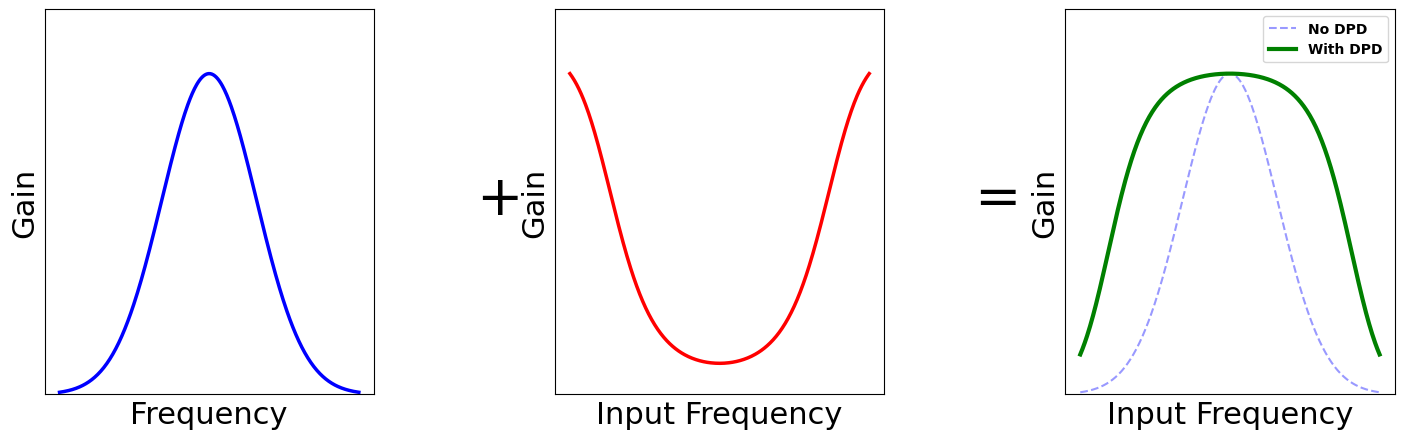

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the frequency range
f = np.linspace(-2, 2, 400)

# 1. PA Frequency Response (Linear Distortion)
pa_response = np.exp(- (f**2) / 0.8)

# 2. DPD Profile (Inverse Filter)
dpd_response = 1.0 / (pa_response + 0.1)
dpd_response = dpd_response / np.max(dpd_response) * 1.0 

# 3. Corrected Response (Total System)
total_response = pa_response * (1.0 / (pa_response + 0.05))
total_response = total_response / np.max(total_response)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: PA Response
axes[0].plot(f, pa_response, color='blue', linewidth=2.5)
axes[0].set_xlabel('Frequency', fontsize=22)
axes[0].set_ylabel('Gain', fontsize=22)
axes[0].set_ylim(0, 1.2)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].grid(False)

# Plot 2: DPD Profile
axes[1].plot(f, dpd_response, color='red', linewidth=2.5)
axes[1].set_xlabel('Input Frequency', fontsize=22)
axes[1].set_ylabel('Gain', fontsize=22)
axes[1].set_ylim(0, 1.2)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].grid(False)

# Plot 3: Resulting System
axes[2].plot(f, pa_response, color='blue', linestyle='--', alpha=0.4, label='No DPD')
axes[2].plot(f, total_response, color='green', linewidth=3, label='With DPD')
axes[2].set_xlabel('Input Frequency', fontsize=22)
axes[2].set_ylabel('Gain', fontsize=22)
axes[2].set_ylim(0, 1.2)
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].legend()
axes[2].grid(False)

# Add "Plus" and "Equals" symbols in the gaps
fig.text(0.373, 0.5, '+', fontsize=40, va='center', ha='center', fontweight='light')
fig.text(0.705, 0.5, '=', fontsize=40, va='center', ha='center', fontweight='light')

# Use subplots_adjust to create explicit gaps for the symbols
plt.subplots_adjust(left=0.07, right=0.97, wspace=0.55)
plt.savefig('dpd_frequency_compensation.png', dpi=150, bbox_inches='tight')
plt.show()